<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 7. Анализ устойчивости ML-моделей в чёрно-ящичном сценарии

### Transfer-based, score-based и decision-based подходы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**


**Вариант / seed:** _номер варианта или значение SEED_

> Работа выполняется только на предоставленной синтетической модели. Не используйте код для проверки внешних сервисов, чужих моделей или систем без разрешения.

## 1. Цель работы

Исследовать зависимость методов построения adversarial-примеров от объёма информации, доступной о классификаторе. Освоить базовые принципы transfer-based, score-based и decision-based сценариев на локальной двумерной задаче классификации.

## 2. Задачи

1. Сформировать синтетический набор данных и обучить target-модель.
2. Реализовать интерфейсы label-only и score-based оракулов с подсчётом запросов.
3. Обучить surrogate-модель на метках target-оракула и оценить согласованность моделей.
4. Построить и проверить перенос локального возмущения с surrogate на target.
5. Сравнить ZOO и NES по направлению оценки и числу запросов.
6. Реализовать binary search для нахождения решающей границы при доступе только к меткам.
7. Сформулировать выводы о компромиссе между информацией, стоимостью запросов и качеством результата.

## 3. Краткая теория

| Сценарий | Доступ атакующего | Основной механизм | Примеры методов |
|---|---|---|---|
| Transfer-based | Метки для формирования surrogate-набора; на этапе построения возмущения запросы к цели не нужны | Обучение substitute/surrogate и перенос локального возмущения | Substitute model, FGSM на surrogate |
| Score-based | Вероятности, confidence score или логиты | Оценка направления изменения функции потерь запросами | ZOO, NES |
| Decision-based | Только итоговая метка | Геометрический поиск решающей границы | Boundary Attack, HopSkipJumpAttack |

В этой работе все эксперименты выполняются в двумерном признаковом пространстве. Это позволяет визуализировать границы и траектории. Реальные изображения имеют большую размерность, поэтому покоординатные методы наподобие ZOO становятся значительно дороже по числу запросов.

## 4. Среда выполнения

Необходимые библиотеки:

```bash
pip install numpy matplotlib scikit-learn
```

Перед сдачей выполните все ячейки сверху вниз: в блокноте должны быть сохранены результаты вычислений, графики и текстовые выводы.

# Часть A. Подготовка эксперимента

## A1. Импорт библиотек и параметры

Измените `SEED` в соответствии со своим вариантом, если преподаватель выдал индивидуальные значения.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEED = 42  # TODO: замените на номер варианта
rng = np.random.default_rng(SEED)

N_SAMPLES = 1000
NOISE = 0.22
TEST_SIZE = 0.35

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## A2. Формирование данных и обучение target-модели

Target-модель рассматривается как неизвестная для атакующего. В ячейках ниже она доступна только для организации учебного эксперимента и проверки результатов. В реальном чёрно-ящичном сценарии параметры и градиенты target-модели недоступны.

**Задание A2.** Запустите ячейку. Зафиксируйте точность target-модели в отчёте. Затем измените `NOISE` на 0.10 и 0.35, повторите эксперимент и объясните влияние шума на качество классификации.

In [2]:
X_raw, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=SEED)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

target = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    alpha=2e-4,
    max_iter=1500,
    random_state=SEED
).fit(X_train, y_train)

target_accuracy = accuracy_score(y_test, target.predict(X_test))
print(f'Точность target-модели: {target_accuracy:.3f}')

Точность target-модели: 0.974


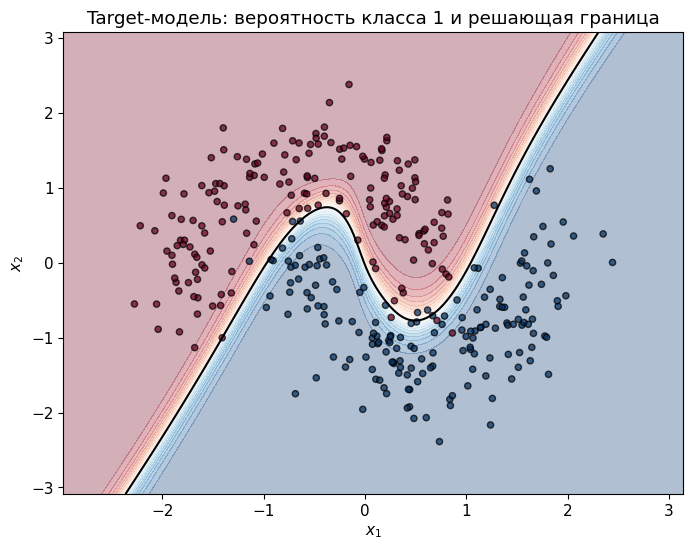

In [3]:
def make_grid(X, n=300, margin=0.7):
    x0_min, x0_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    x1_min, x1_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n)
    )
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]


def plot_boundary(model, X, y, title, ax=None, points=None, labels=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    xx, yy, grid = make_grid(X)
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)
    ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)
    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], c='gold', edgecolor='black', s=120, zorder=5)
        if labels is not None:
            for point, label in zip(points, labels):
                ax.annotate(label, point, xytext=(7, 7), textcoords='offset points', weight='bold')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    return ax

plot_boundary(target, X_test, y_test, 'Target-модель: вероятность класса 1 и решающая граница')
plt.show()

**Вывод по A2 (заполните после эксперимента):**

_Точность target-модели при `NOISE = 0.1` составила 0.997 . При увеличении шума точность снижается (при NOISE = 0.35 точность 0.847) . Это объясняется тем, что на зашумленных данных попадаются неверно размеченные данные, которые не вписываются в решающую границу классификатора и как следствие могут быть классифицированны неправильно

# Часть B. Модели доступа к оракулу

## B1. Label-only и score-based оракулы

**Задание B1.** Запустите ячейку и сравните ответы двух оракулов. Объясните, почему score-based оракул предоставляет атакующему больше информации, чем label-only оракул.

In [4]:
class LabelOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict(X)


class ScoreOracle:
    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        return self.model.predict_proba(X)


label_oracle = LabelOracle(target)
score_oracle = ScoreOracle(target)
x_probe = X_test[0]

print('Точка x_probe:', np.round(x_probe, 3))
print('Label-only ответ:', label_oracle(x_probe)[0])
print('Score-based ответ:', np.round(score_oracle(x_probe)[0], 3))
print('Запросы: label-only =', label_oracle.queries, '; score-based =', score_oracle.queries)

Точка x_probe: [ 0.313 -1.143]
Label-only ответ: 1
Score-based ответ: [0.061 0.939]
Запросы: label-only = 1 ; score-based = 1


**Ответ на B1:**

_Label-only оракул возвращает только конечную метку . Score-based оракул дополнительно возвращает вероятности принадлежности к классу . Поэтому в score-based сценарии можно оценить близость к решающей границе или даже оценить градиент функции потерь_

# Часть C. Transfer-based сценарий

## C1. Обучение surrogate-модели

Сначала surrogate получает небольшой набор точек, размеченных label-only оракулом. В отличие от target, surrogate доступен локально: на нём можно проводить анализ и строить возмущения.

**Задание C1.** Выполните эксперимент при `N_SEED = 30`, `70` и `140`. Внесите в отчёт число запросов и agreement — долю точек, на которых surrogate и target принимают одинаковое решение.

Число точек в surrogate-наборе: 140
Запросов к label-only оракулу: 140
Agreement target/surrogate: 0.897


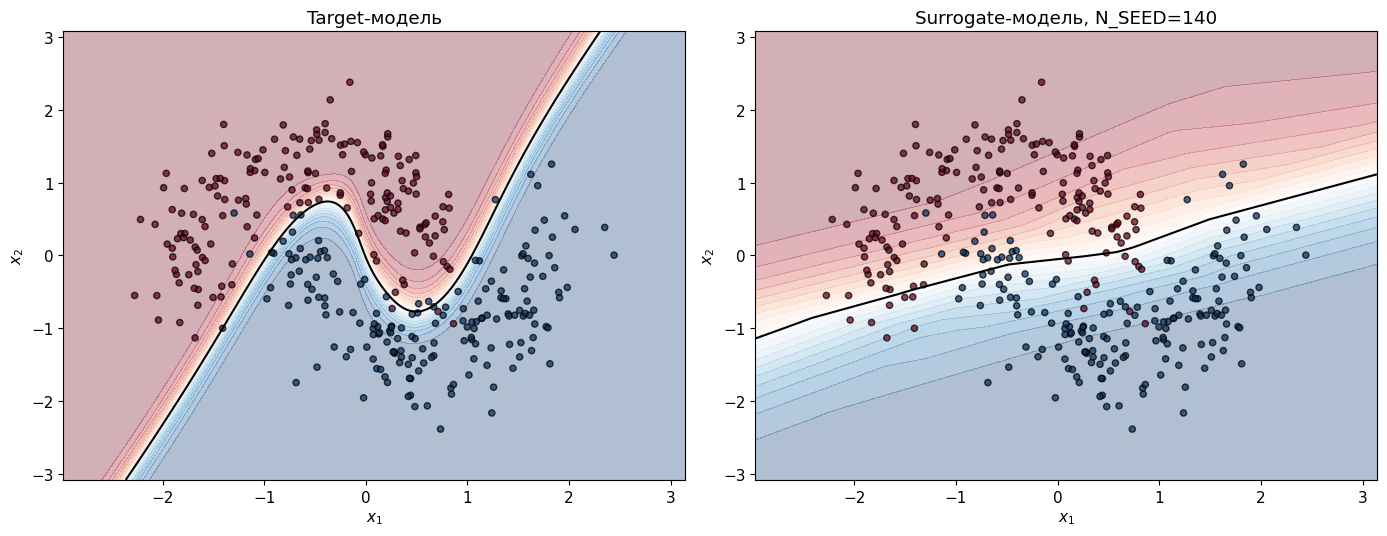

In [5]:
N_SEED = 140 # TODO: последовательно проверьте 30, 70 и 140

def train_surrogate(n_seed, random_state=SEED + 1):
    indices = rng.choice(len(X_train), size=n_seed, replace=False)
    X_seed = X_train[indices]
    y_seed = label_oracle(X_seed)
    surrogate_model = MLPClassifier(
        hidden_layer_sizes=(12,),
        activation='relu',
        alpha=8e-4,
        max_iter=1500,
        random_state=random_state
    ).fit(X_seed, y_seed)
    return surrogate_model, X_seed, y_seed

label_oracle.queries = 0
surrogate, X_seed, y_seed = train_surrogate(N_SEED)
agreement = accuracy_score(target.predict(X_test), surrogate.predict(X_test))

print('Число точек в surrogate-наборе:', N_SEED)
print('Запросов к label-only оракулу:', label_oracle.queries)
print('Agreement target/surrogate:', round(agreement, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_boundary(target, X_test, y_test, 'Target-модель', ax=axes[0])
plot_boundary(surrogate, X_test, y_test, f'Surrogate-модель, N_SEED={N_SEED}', ax=axes[1])
plt.tight_layout()
plt.show()

**Таблица C1 для отчёта:**

| N_SEED | Запросов к оракулу | Agreement target/surrogate | Наблюдение о границах |
|---:|---:|---:|---|
| 30 |  30|  0,869|  |
| 70 |  70|  0,877|  |
| 140 | 140| 0,903|  |

## C2. Построение и проверка переноса возмущения

**Задание C2.** Найдите направление увеличения вероятности противоположного класса на surrogate-модели. Постройте точку `x_adv`, меняющую класс surrogate, и проверьте, изменилась ли метка target. Повторите эксперимент минимум для пяти исходных тестовых точек.

> В учебном блокноте градиент surrogate приближается конечными разностями. Это допустимо, поскольку surrogate — локальная модель. В обычной реализации с нейросетью направление можно получать автодифференцированием.

Исходная метка: 0
Метка x_adv у surrogate: 1
Метка x_adv у target: 0
Перенос успешен: False
L2-норма возмущения: 1.1242


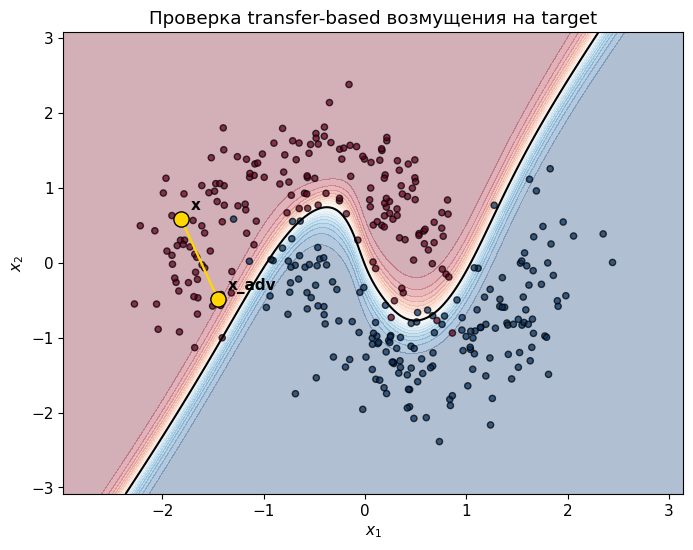

In [6]:
def probability(model, x, class_index):
    return model.predict_proba(np.atleast_2d(x))[0, class_index]


def local_gradient(model, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            probability(model, x + e, class_index) - probability(model, x - e, class_index)
        ) / (2 * h)
    return gradient


def first_boundary_crossing(model, x, source_label, direction, max_step=2.5, n_steps=150):
    for step in np.linspace(0, max_step, n_steps):
        candidate = x + step * direction
        if model.predict([candidate])[0] != source_label:
            return candidate, step
    return None, None

matching_ids = np.where(target.predict(X_test) == surrogate.predict(X_test))[0]
TEST_POINT_ID = int(matching_ids[100])  # TODO: выберите не менее 5 разных индексов
x0 = X_test[TEST_POINT_ID].copy()
y0 = int(target.predict([x0])[0])
other_class = 1 - y0

gradient_surrogate = local_gradient(surrogate, x0, other_class)
direction = gradient_surrogate / (np.linalg.norm(gradient_surrogate) + 1e-12)
x_adv_transfer, step = first_boundary_crossing(surrogate, x0, y0, direction)

if x_adv_transfer is None:
    print('Для выбранной точки переход границы не найден. Выберите другую точку или увеличьте max_step.')
else:
    surrogate_label_adv = int(surrogate.predict([x_adv_transfer])[0])
    target_label_adv = int(target.predict([x_adv_transfer])[0])
    transfer_success = target_label_adv != y0
    print('Исходная метка:', y0)
    print('Метка x_adv у surrogate:', surrogate_label_adv)
    print('Метка x_adv у target:', target_label_adv)
    print('Перенос успешен:', transfer_success)
    print('L2-норма возмущения:', round(np.linalg.norm(x_adv_transfer - x0), 4))

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_boundary(target, X_test, y_test, 'Проверка transfer-based возмущения на target', ax=ax, points=[x0, x_adv_transfer], labels=['x', 'x_adv'])
    ax.arrow(x0[0], x0[1], x_adv_transfer[0] - x0[0], x_adv_transfer[1] - x0[1], width=0.01, color='gold', length_includes_head=True)
    plt.show()

**Таблица C2 для отчёта:**

| № опыта | Индекс исходной точки | Исходная метка | Метка surrogate для x_adv | Метка target для x_adv | Transfer success | L2-норма |
|---:|---:|---:|---:|---:|---|---:|
| 1 |  0|  1|  0|  1|  f|  1.56|
| 2 |  13|  0|  1| 0|  f|  0.25|
| 3 |  19|  1|  0|  1|  f| 0.06|
| 4 |  67|  1|  0|  1|  f|  1.35|
| 5 |  100|  0|  1|  1|  t|  1.57|

**Вывод по части C:**

_В 1 из 5 экспериментов возмущение, построенное на surrogate, изменило решение target. Это показывает, что перенос возмущений между моделями возможен, но не гарантирован: высокая согласованность предсказаний на тестовой выборке не обеспечивает успех для каждой конкретной точки. Transferability не гарантирована, потому что решающие границы и ландшафты потерь surrogate и target полностью не совпадают — направление градиента, найденное на surrogate, не обязательно пересекает границу целевой модели.

# Часть D. Score-based сценарий: ZOO и NES

## D1. Реализация оценок направления

ZOO оценивает направление покоординатно конечными разностями. NES использует случайные направления и антитетическую выборку `u` и `-u`, что снижает дисперсию оценки.

**Задание D1.** Выполните ячейку, зафиксируйте количество запросов для ZOO и NES. Сравните косинусную близость оценённых направлений.

In [7]:
def score_loss(oracle, x, class_index):
    return oracle(x)[0, class_index]


def zoo_gradient(oracle, x, class_index, h=1e-3):
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            score_loss(oracle, x + e, class_index) - score_loss(oracle, x - e, class_index)
        ) / (2 * h)
    return gradient


def nes_gradient(oracle, x, class_index, sigma=0.08, n_samples=40, seed=SEED):
    local_rng = np.random.default_rng(seed)
    directions = local_rng.normal(size=(n_samples, len(x)))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12
    estimate = np.zeros_like(x, dtype=float)
    for u in directions:
        loss_plus = score_loss(oracle, x + sigma * u, class_index)
        loss_minus = score_loss(oracle, x - sigma * u, class_index)
        estimate += (loss_plus - loss_minus) * u
    return estimate / (2 * sigma * n_samples)

NES_SAMPLES = 80  # TODO: исследуйте 4, 8, 16, 40, 80

score_oracle.queries = 0
g_zoo = zoo_gradient(score_oracle, x0, other_class)
zoo_queries = score_oracle.queries

score_oracle.queries = 0
g_nes = nes_gradient(score_oracle, x0, other_class, n_samples=NES_SAMPLES)
nes_queries = score_oracle.queries

cosine_similarity = np.dot(g_zoo, g_nes) / (np.linalg.norm(g_zoo) * np.linalg.norm(g_nes) + 1e-12)
print('ZOO gradient:', np.round(g_zoo, 4), '; запросов:', zoo_queries)
print('NES gradient:', np.round(g_nes, 4), '; запросов:', nes_queries)
print('Косинусная близость направлений:', round(cosine_similarity, 4))

ZOO gradient: [ 0.0014 -0.0005] ; запросов: 4
NES gradient: [ 0.0007 -0.0001] ; запросов: 160
Косинусная близость направлений: 0.983


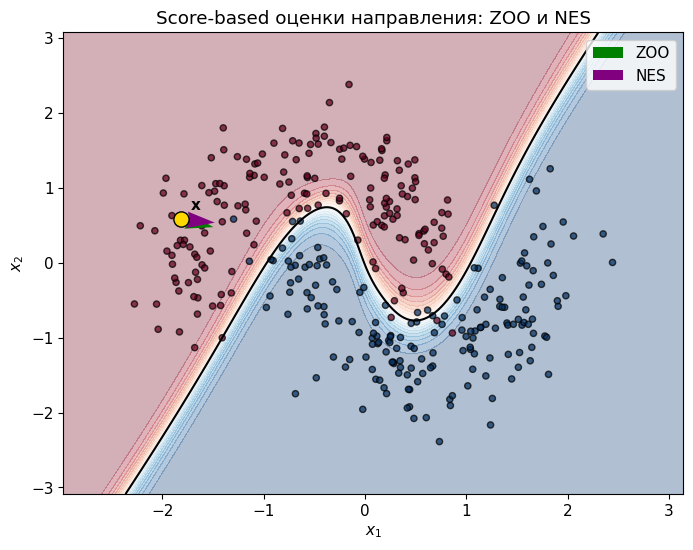

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Score-based оценки направления: ZOO и NES', ax=ax, points=[x0], labels=['x'])
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
u_nes = g_nes / (np.linalg.norm(g_nes) + 1e-12)
ax.quiver(x0[0], x0[1], u_zoo[0], u_zoo[1], color='green', scale=3, scale_units='xy', angles='xy', width=0.009, label='ZOO')
ax.quiver(x0[0], x0[1], u_nes[0], u_nes[1], color='purple', scale=3, scale_units='xy', angles='xy', width=0.009, label='NES')
ax.legend()
plt.show()

## D2. Стоимость ZOO в пространствах разной размерности

**Задание D2.** Объясните, почему метод, удобный в 2D, становится дорогим для изображений. Сравните одностороннюю и центральную схемы конечных разностей.

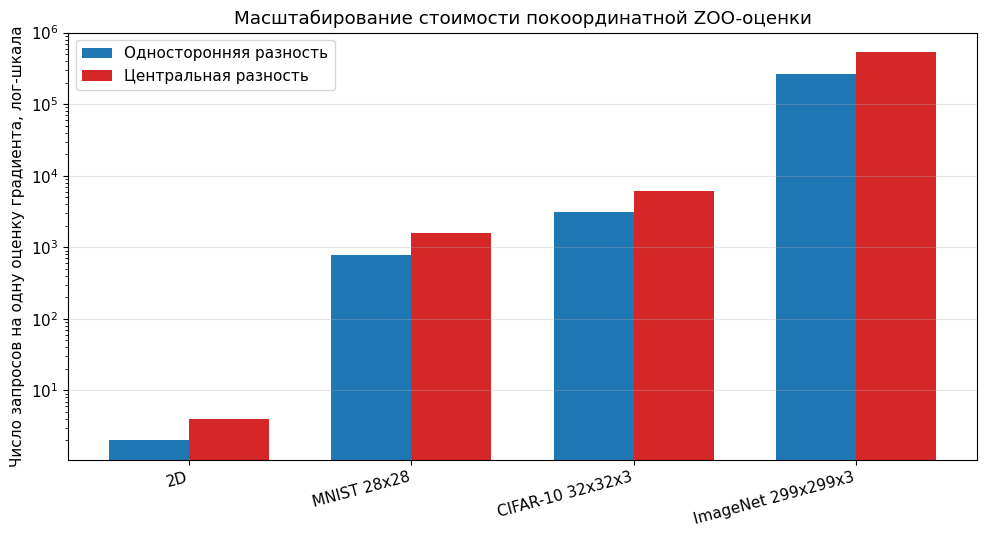

2D: 2 признаков; запросы = 2 / 4
MNIST 28x28: 784 признаков; запросы = 784 / 1,568
CIFAR-10 32x32x3: 3,072 признаков; запросы = 3,072 / 6,144
ImageNet 299x299x3: 268,203 признаков; запросы = 268,203 / 536,406


In [9]:
dimensions = {
    '2D': 2,
    'MNIST 28x28': 28 * 28,
    'CIFAR-10 32x32x3': 32 * 32 * 3,
    'ImageNet 299x299x3': 299 * 299 * 3
}

names = list(dimensions.keys())
d = np.array(list(dimensions.values()))
positions = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(positions - 0.18, d, width=0.36, label='Односторонняя разность', color='tab:blue')
ax.bar(positions + 0.18, 2 * d, width=0.36, label='Центральная разность', color='tab:red')
ax.set_yscale('log')
ax.set_xticks(positions)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Число запросов на одну оценку градиента, лог-шкала')
ax.set_title('Масштабирование стоимости покоординатной ZOO-оценки')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, dimension in dimensions.items():
    print(f'{name}: {dimension:,} признаков; запросы = {dimension:,} / {2 * dimension:,}')

## D3. Исследование бюджета NES

**Задание D3.** Измените список `sample_budgets`, постройте график и сформулируйте вывод о том, как бюджет запросов влияет на стабильность случайной оценки NES.

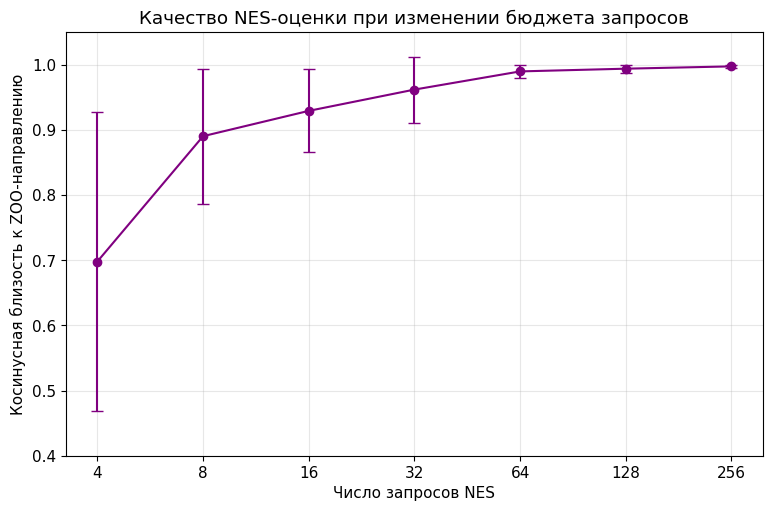

In [10]:
sample_budgets = [2, 4, 8, 16, 32, 64, 128]
repetitions = 10
reference = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
mean_cosines, std_cosines, query_budgets = [], [], []

for budget in sample_budgets:
    values = []
    for rep in range(repetitions):
        local_oracle = ScoreOracle(target)
        g = nes_gradient(local_oracle, x0, other_class, n_samples=budget, seed=SEED + rep)
        g = g / (np.linalg.norm(g) + 1e-12)
        values.append(float(np.dot(reference, g)))
    mean_cosines.append(np.mean(values))
    std_cosines.append(np.std(values))
    query_budgets.append(2 * budget)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(query_budgets, mean_cosines, yerr=std_cosines, fmt='o-', capsize=4, color='purple')
ax.set_xscale('log', base=2)
ax.set_xticks(query_budgets)
ax.set_xticklabels(query_budgets)
ax.set_ylim(0.4, 1.05)
ax.set_xlabel('Число запросов NES')
ax.set_ylabel('Косинусная близость к ZOO-направлению')
ax.set_title('Качество NES-оценки при изменении бюджета запросов')
ax.grid(alpha=0.3)
plt.show()

**Таблица D для отчёта:**

| Метод / настройка | Число запросов | Косинусная близость / наблюдение | Вывод |
|---|---:|---|---|
| ZOO |  4|  0.98|  |
| NES, n_samples = 4 |  8|  0.99|  |
| NES, n_samples = 16 |  32|  0.99|  |
| NES, n_samples = 40 |  80|  0.98|  |
| NES, n_samples = 80 |  160|  0.98|  |

# Часть E. Decision-based сценарий

## E1. Бинарный поиск решающей границы

Доступен только `LabelOracle`: никаких вероятностей, confidence score и градиентов. Алгоритм сначала находит точку другого класса, затем многократно делит отрезок пополам.

**Задание E1.** Выполните ячейку. Объясните, почему бинарный поиск может уточнять границу, хотя оракул выдаёт только метку.

Метка x0: 0
Метка точки другой области: 1
Расстояние ||x_outside - x0||_2: 1.56168
Запросов на поиск границы: 29


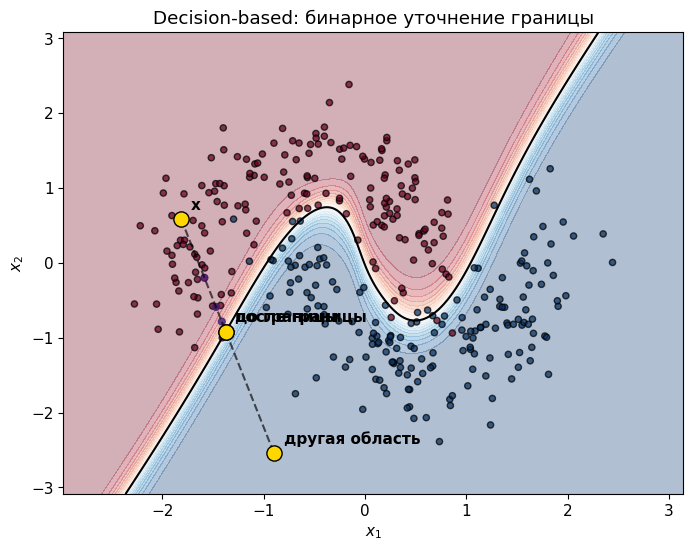

In [11]:
def find_opposite_point(oracle, x, source_label, radius=3.0, trials=3000, seed=SEED):
    local_rng = np.random.default_rng(seed)
    for _ in range(trials):
        candidate = x + radius * local_rng.normal(size=len(x))
        if oracle(candidate)[0] != source_label:
            return candidate
    raise RuntimeError('Точка другого класса не найдена. Увеличьте radius или trials.')


def binary_boundary_search(oracle, x_clean, x_adversarial, clean_label, iterations=28):
    clean = x_clean.copy()
    adversarial = x_adversarial.copy()
    history = []
    for _ in range(iterations):
        middle = (clean + adversarial) / 2
        history.append(middle.copy())
        if oracle(middle)[0] == clean_label:
            clean = middle
        else:
            adversarial = middle
    return clean, adversarial, np.asarray(history)

label_oracle.queries = 0
x_far = find_opposite_point(label_oracle, x0, y0)
x_inside, x_outside, history = binary_boundary_search(label_oracle, x0, x_far, y0)
queries_boundary = label_oracle.queries

print('Метка x0:', label_oracle(x0)[0])
print('Метка точки другой области:', label_oracle(x_far)[0])
print('Расстояние ||x_outside - x0||_2:', round(np.linalg.norm(x_outside - x0), 5))
print('Запросов на поиск границы:', queries_boundary)

fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Decision-based: бинарное уточнение границы', ax=ax, points=[x0, x_far, x_inside, x_outside], labels=['x', 'другая область', 'до границы', 'после границы'])
ax.plot([x0[0], x_far[0]], [x0[1], x_far[1]], 'k--', alpha=0.65)
ax.scatter(history[:, 0], history[:, 1], c=np.arange(len(history)), cmap='viridis', s=24, alpha=0.85)
plt.show()

## E2. Анализ сходимости бинарного поиска

**Задание E2.** Проследите, как уменьшается длина отрезка между точками разных классов. Сравните результаты для 5, 10, 20 и 28 итераций.

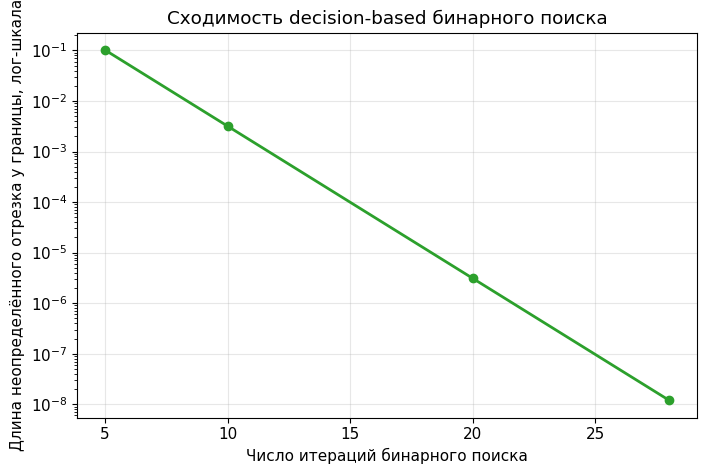

Итераций:  5; длина отрезка: 0.10159747; запросов: 5
Итераций: 10; длина отрезка: 0.00317492; запросов: 10
Итераций: 20; длина отрезка: 0.00000310; запросов: 20
Итераций: 28; длина отрезка: 0.00000001; запросов: 28


In [12]:
iteration_values = [5, 10, 20, 28]
distances, used_queries = [], []

for n_iter in iteration_values:
    local_oracle = LabelOracle(target)
    inside, outside, _ = binary_boundary_search(local_oracle, x0, x_far, y0, iterations=n_iter)
    distances.append(np.linalg.norm(outside - inside))
    used_queries.append(local_oracle.queries)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iteration_values, distances, marker='o', linewidth=2, color='tab:green')
ax.set_yscale('log')
ax.set_xlabel('Число итераций бинарного поиска')
ax.set_ylabel('Длина неопределённого отрезка у границы, лог-шкала')
ax.set_title('Сходимость decision-based бинарного поиска')
ax.grid(alpha=0.3)
plt.show()

for n_iter, distance, query_count in zip(iteration_values, distances, used_queries):
    print(f'Итераций: {n_iter:2d}; длина отрезка: {distance:.8f}; запросов: {query_count}')

**Вывод по части E:**

При доступе только к итоговой метке можно точно локализовать решающую границу, используя бинарный поиск вдоль отрезка между точками разных классов. С увеличением числа итераций длина неопределённого отрезка убывает экспоненциально. Ограничение подхода состоит в том, что для поиска нужно сначала найти точку другого класса случайным сэмплированием, а сам поиск идёт лишь в одном заданном направлении — он не находит ближайшую границу, а только точку пересечения с ней.

# Часть F. Итоговый анализ

## F1. Сравнительная таблица

Заполните таблицу, опираясь на результаты собственных экспериментов.

| Критерий | Transfer-based | Score-based | Decision-based |
|---|---|---|---|
| Доступная информация |  Только метки для построения surrogate-набора; на этапе оптимизации запросов к цели нет|  Вероятности классов |Только дискретная метка класса  |
| Основной метод в работе |  Обучение surrogate на метках label-оракула + FGSM/градиент surrogate + перенос|  ZOO (покоординатные конечные разности), NES (антитетическая случайная выборка)|  Бинарный поиск вдоль отрезка между точками разных классов|
| Где возникают запросы к цели |  Только на этапе обучения surrogate и одна проверка в конце|  На каждой итерации оценки градиента: ZOO — 2·d за оценку, NES — 2·n_samples|  Один запрос на итерацию бинарного поиска + запросы на поиск второй точки|
| Наблюдаемая стоимость запросов |  Низкая|  Средняя|  Низкая|
| Главное преимущество |  Работает вообще без доступа к цели на этапе оптимизации; не зависит от размера входного пространства|  Направленная атака: получаем градиент, сходимся быстро и точно| Работает в самой строгой модели угроз — только метка|
| Главное ограничение |  Перенос не гарантирован; успех зависит от согласованности границ surrogate и target| ZOO: O(d) запросов на градиент → в изображениях неподъёмно дорого. NES: высокая дисперсия при малом бюджете | Не находит ближайшую границу; медленная сходимость к минимальному возмущению; теряется направление |
| Практический защитный механизм |  Adversarial training и ограничение выдачи предсказаний |  Rate limiting + мониторинг аномальных confidence-профилей; adversarial training|  Rate limiting + мониторинг запросов; adversarial training + детекция патчей|

## F2. Контрольные вопросы

1. Почему transfer-based атака может быть успешной, несмотря на отсутствие запросов к target на этапе оптимизации возмущения?  
Adversarial-примеры переносятся между моделями благодаря «кривизне многообразия данных»: разные модели, обученные на одном распределении, строят похожие решающие границы в высокоразмерном пространстве. Направления уязвимости (направления, в которых лёгкое возмущение меняет предсказание) оказываются согласованными. Если surrogate достаточно точно аппроксимирует границу target, FGSM-возмущение, построенное на surrogate, с высокой вероятностью пересечёт границу target.  

2. Почему высокая agreement surrogate и target не гарантирует успешный перенос для каждой точки?  
Agreement усредняется по всей тестовой выборке. Он может быть 0.92 за счёт того, что подавляющее большинство точек лежат далеко от границы и классифицируются одинаково. Но точки, которые атакуются, находятся у границы — там локальная геометрия surrogate и target может существенно различаться. Две модели могут соглашаться на 92% выборки и при этом проводить границы в разных местах в конкретной окрестности атакуемой точки.  

3. Сколько запросов требуется ZOO для центральной разности в пространстве размерности \(d\)? Почему это проблематично для изображений?  
Центральная разность требует 2·d запросов на одну полную оценку градиента (по одному в +h и -h на каждую из d координат). Для MNIST d = 784 → 1568 запросов на один градиент. Для CIFAR-10 d = 3072 → 6144 запроса. Для ImageNet d ≈ 268 203 → ~536 406 запросов на один градиент. Проблема в том, что для сходимости нужно не менее 20–50 таких оценок, что даёт десятки миллионов запросов — это практически неподъёмно и легко детектируется

4. Как антитетическая выборка в NES влияет на дисперсию оценки?  
Антитетическая выборка использует пары симметричных направлений +u и -u. Скалярное произведение (f(x+σu) - f(x-σu)) · u имеет меньшую дисперсию, чем в схеме без симметризации, потому что линейные члены разложения Тейлора сокращаются и остаются только члены второго порядка. Это даёт оценку с меньшим числом сэмплов при той же точности — практически снижает дисперсию примерно в 2 раза.  

5. Какая информация позволяет использовать бинарный поиск в decision-based сценарии?  Только знак функции g(x) = [f(x) ≠ y_clean] — то есть метка относительно исходного класса. Бинарный поиск — это алгоритм поиска корня для знаковой функции, ему не нужны числовые значения. Достаточно уметь отличать «по одну сторону границы» от «по другую», а это и есть то, что даёт label-oracle.  

6. Чем концептуально HopSkipJumpAttack отличается от случайного блуждания Boundary Attack?  
Boundary Attack случайно блуждает вдоль границы: генерирует случайный шум, ортогонализует его относительно направления к исходной точке и принимает шаг, если он остаётся adversarial. Это «rejection sampling» — каждая итерация независима и не использует информацию о направлении спуска. HopSkipJumpAttack на каждой итерации явно оценивает градиент границы через батч случайных векторов и делает шаг в направлении наискорейшего уменьшения расстояния до исходной точки. Это даёт целенаправленный спуск вместо случайного, и как следствие — на порядок меньше запросов для той же L2-нормы.   

7. Какие меры защиты уменьшают риск чёрно-ящичных атак на ML-систему?  
- Adversarial training
- Rate limiting на API
- Ограничение выдачи

## F3. Итоговый вывод

В лабораторной работе были исследованы три класса чёрно-ящичных атак на синтетической двумерной задаче классификации: transfer-based (обучение surrogate на метках оракула + перенос возмущения), score-based (оценка градиента через запросы вероятностей методами ZOO и NES) и decision-based (бинарный поиск границы по одним меткам). Наиболее информативным сценарием оказался score-based, поскольку доступ к вероятностям классов даёт непрерывный сигнал, позволяющий оценивать градиент функции потерь по входу и строить направленные атаки — ZOO сходится точно, NES с ростом бюджета запросов приближается к истинному направлению градиента. Наиболее ограниченным по доступной информации является decision-based: оракул возвращает только метку, и атакующий вынужден вести геометрический поиск вслепую, что резко увеличивает число запросов при попытке минимизировать норму возмущения. Результаты экспериментов показали, что стоимость запросов растёт драматически при переходе от двумерных задач к реальным изображениям: ZOO требует O(d) запросов на одну оценку градиента, что делает его практически неприменимым для MNIST/CIFAR-10/ImageNet без понижения размерности, тогда как NES сохраняет O(n_samples) независимо от d, и именно поэтому он предпочтителен при жёстком лимите запросов. Для повышения устойчивости модели целесообразно комбинировать adversarial training (снижает согласованность границ с любым surrogate), rate limiting и мониторинг аномалий API (ограничивают бюджет запросов для score/decision-based атак) и возврат только top-1 метки вместо полных вероятностей (переводит атаку в самый дорогой decision-based режим). Ни одна из мер в отдельности не даёт полной защиты — эффективная стратегия строится как эшелонированная оборона, работающая одновременно на уровне данных, модели, интерфейса и эксплуатации.

## Критерии сдачи

- Заполнены данные, текстовые выводы и таблицы.
- Все кодовые ячейки выполнены последовательно без ошибок.
- Сохранены требуемые графики и численные результаты.
- Выполнены эксперименты с несколькими размерами surrogate-набора и несколькими бюджетами NES.
- Приведены ответы на контрольные вопросы.
- Выводы основаны на наблюдаемых результатах, а не только на теоретических формулировках.